# CMPINF 2100 - Final Project - Andrew Hornyak

### Spotify Songs - Final Project - Part F - Cross Validation - Supplemental

#### Examining the best model on new data using Cross Validation

### NOTES:

* Cross Validation for **`Part F`** begin on **ln[35]**
* Everything before is data prep

### Import Modules

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

import seaborn as sns

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.cluster import hierarchy

In [3]:
import statsmodels.formula.api as smf
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

In [4]:
from sklearn.model_selection import StratifiedKFold 

In [5]:
import statsmodels.formula.api as smf

In [6]:
from sklearn.linear_model import LogisticRegression

In [7]:
from patsy import dmatrices

In [8]:
from sklearn.model_selection import cross_val_score

In [9]:
from sklearn.pipeline import Pipeline

In [10]:
from sklearn.compose import ColumnTransformer

In [11]:
import patsy
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [12]:
song_data_url = 'https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-01-21/spotify_songs.csv'

In [13]:
song_data_df = pd.read_csv(song_data_url)

In [14]:
song_data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  object 
 1   track_name                32828 non-null  object 
 2   track_artist              32828 non-null  object 
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  object 
 5   track_album_name          32828 non-null  object 
 6   track_album_release_date  32833 non-null  object 
 7   playlist_name             32833 non-null  object 
 8   playlist_id               32833 non-null  object 
 9   playlist_genre            32833 non-null  object 
 10  playlist_subgenre         32833 non-null  object 
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key                       32833 non-null  int64  
 14  loudne

In [15]:
#### Remove duplicates

song_clean_df = song_data_df.drop_duplicates(subset='track_id', keep='first')

In [16]:
song_clean_df = song_clean_df.reset_index()

In [17]:
song_clean_df = song_clean_df.rename(columns={"index":"row_id"})

In [18]:
song_clean_df.drop('row_id', axis=1, inplace=True)

In [19]:
song_clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28356 entries, 0 to 28355
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  28356 non-null  object 
 1   track_name                28352 non-null  object 
 2   track_artist              28352 non-null  object 
 3   track_popularity          28356 non-null  int64  
 4   track_album_id            28356 non-null  object 
 5   track_album_name          28352 non-null  object 
 6   track_album_release_date  28356 non-null  object 
 7   playlist_name             28356 non-null  object 
 8   playlist_id               28356 non-null  object 
 9   playlist_genre            28356 non-null  object 
 10  playlist_subgenre         28356 non-null  object 
 11  danceability              28356 non-null  float64
 12  energy                    28356 non-null  float64
 13  key                       28356 non-null  int64  
 14  loudne

In [20]:
# updating 'key' to category to perform analysis as a categorical variable

song_clean_df['key'] = song_data_df['key'].astype('category')

In [21]:
# updating 'mode' to category to perform analysis as a categorical variable

song_clean_df['mode'] = song_data_df['mode'].astype('category')

In [22]:
song_clean_df['track_pop_median'] = np.where( song_clean_df.track_popularity > song_clean_df.track_popularity.median() , 1, 0 )

#song_clean_df['track_pop_median'] = song_clean_df['track_pop_median'].astype('category')

In [23]:
song_clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28356 entries, 0 to 28355
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   track_id                  28356 non-null  object  
 1   track_name                28352 non-null  object  
 2   track_artist              28352 non-null  object  
 3   track_popularity          28356 non-null  int64   
 4   track_album_id            28356 non-null  object  
 5   track_album_name          28352 non-null  object  
 6   track_album_release_date  28356 non-null  object  
 7   playlist_name             28356 non-null  object  
 8   playlist_id               28356 non-null  object  
 9   playlist_genre            28356 non-null  object  
 10  playlist_subgenre         28356 non-null  object  
 11  danceability              28356 non-null  float64 
 12  energy                    28356 non-null  float64 
 13  key                       28356 non-null  cate

In [24]:
columns_to_drop = ['track_id', 'track_name', 'track_artist', 'track_popularity','track_album_id', 'track_album_name', 'track_album_release_date','playlist_name', 'playlist_id', 'playlist_subgenre']

song_clean_df = song_clean_df.drop(columns=columns_to_drop)

song_clean_df = song_clean_df.reset_index()

song_clean_df = song_clean_df.rename(columns={"index":"row_id"})

song_clean_df.drop('row_id', axis=1, inplace=True)

In [25]:
song_clean_copy_df = song_clean_df.copy()

In [26]:
song_clean_copy_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28356 entries, 0 to 28355
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   track_id                  28356 non-null  object  
 1   track_name                28352 non-null  object  
 2   track_artist              28352 non-null  object  
 3   track_popularity          28356 non-null  int64   
 4   track_album_id            28356 non-null  object  
 5   track_album_name          28352 non-null  object  
 6   track_album_release_date  28356 non-null  object  
 7   playlist_name             28356 non-null  object  
 8   playlist_id               28356 non-null  object  
 9   playlist_genre            28356 non-null  object  
 10  playlist_subgenre         28356 non-null  object  
 11  danceability              28356 non-null  float64 
 12  energy                    28356 non-null  float64 
 13  key                       28356 non-null  cate

In [27]:
song_features = ['danceability','energy','loudness','speechiness',
                                    'acousticness','instrumentalness','liveness',
                                    'valence','tempo','duration_ms']

In [28]:
formula_list = [
                'track_pop_median ~ playlist_genre + mode + key + danceability + energy + loudness + speechiness + acousticness + instrumentalness + liveness + valence + tempo + duration_ms',
                'track_pop_median ~ (danceability + energy + loudness + speechiness + acousticness + instrumentalness + liveness + valence + tempo + duration_ms) ** 2',
                'track_pop_median ~ (playlist_genre + mode + key) * (danceability + energy + loudness + speechiness + acousticness + instrumentalness + liveness + valence + tempo + duration_ms)'
                ]

In [29]:
formula_list_trim = [
                'track_pop_median ~ playlist_genre + mode + key + danceability + energy + loudness + speechiness + acousticness + instrumentalness + liveness + valence + tempo + duration_ms',
                'track_pop_median ~ (danceability + energy + loudness + speechiness + acousticness + instrumentalness + liveness + valence + tempo + duration_ms) ** 2',
                'track_pop_median ~ (playlist_genre + mode + key) * (danceability + energy + loudness + speechiness + acousticness + instrumentalness + liveness + valence + tempo + duration_ms)'
                ]

In [30]:
a_formula = [
            'track_pop_median ~ playlist_genre_latin + playlist_genre_pop + playlist_genre_rb + playlist_genre_rap + playlist_genre_rock + key_1 + key_2 + key_3 + key_4 + key_5 + key_6 + key_7 + key_8 + key_9 + key_10 + key_11 + mode_1 + danceability + energy + loudness + speechiness + acousticness + instrumentalness + liveness + valence + tempo + duration_ms',
            'track_pop_median ~ (danceability + energy + loudness + speechiness + acousticness + instrumentalness + liveness + valence + tempo + duration_ms) ** 2',
            'track_pop_median ~ (playlist_genre_latin + playlist_genre_pop + playlist_genre_rb + playlist_genre_rap + playlist_genre_rock + key_1 + key_2 + key_3 + key_4 + key_5 + key_6 + key_7 + key_8 + key_9 + key_10 + key_11 + mode_1) * (danceability + energy + loudness + speechiness + acousticness + instrumentalness + liveness + valence + tempo + duration_ms)'
]

formula_list = ['track_pop_median ~ 1',
                'track_pop_median ~ playlist_genre + mode + key',
                'track_pop_median ~ danceability_std + energy_std + loudness_std + speechiness_std + acousticness_std + instrumentalness_std + liveness_std + valence_std + tempo_std + duration_ms_std',
                'track_pop_median ~ playlist_genre + mode + key + danceability_std + energy_std + loudness_std + speechiness_std + acousticness_std + instrumentalness_std + liveness_std + valence_std + tempo_std + duration_ms_std',
                'track_pop_median ~ (danceability_std + energy_std + loudness_std + speechiness_std + acousticness_std + instrumentalness_std + liveness_std + valence_std + tempo_std + duration_ms_std) ** 2',
                'track_pop_median ~ (playlist_genre + mode + key) * (danceability_std + energy_std + loudness_std + speechiness_std + acousticness_std + instrumentalness_std + liveness_std + valence_std + tempo_std + duration_ms_std)',
                'track_pop_median ~ playlist_genre + mode + key + (danceability_std + energy_std + loudness_std + speechiness_std + acousticness_std + instrumentalness_std + liveness_std + valence_std + tempo_std + duration_ms_std) ** 2',
                'track_pop_median ~ ((playlist_genre + mode + key + energy_std + loudness_std + danceability_std + speechiness_std + liveness_std + valence_std + tempo_std + duration_ms_std + acousticness_std + instrumentalness_std )  + np.power(acousticness_std,2) + np.power(instrumentalness_std,2)  ) * ((acousticness_std + instrumentalness_std ) ** 2)'
               ]

In [31]:
input_names = song_clean_copy_df.drop(columns=['track_pop_median']).copy().columns.to_list()

In [32]:
output_name = 'track_pop_median'

In [33]:
kf = StratifiedKFold( n_splits=5, shuffle=True, random_state=9483156 )

Initialize the SKLEARN Logistic Regression model to be CONSISTENT with statsmodels.

In [34]:
sk_min_loss = LogisticRegression(penalty=None, solver='lbfgs', fit_intercept=False, max_iter=25000)

## All Models

### Model Used in Final Workbook - Statsmodel - Standarization & Encoding within the Folds

**Model Notes:**

* Uses statsmodel
* uses StandardScaler to standardize continuous variables within the fold
* Uses OneHotEncoder to encode categorical variables within the fold
* Had to update the formulas being used in function call to account for the Encoded Variable Names

In [35]:
def train_and_test_logistic_with_cvz(mod_name, a_formula, data_df, x_names, y_name, cv, threshold=0.5):
    # separate the inputs and output
    input_df = data_df.loc[:, x_names].copy()
    
    # initialize the performance metric storage lists
    train_res = []
    test_res = []
    
    # SPLIT the data and iterate over the folds
    for train_id, test_id in cv.split(input_df.to_numpy(), data_df[y_name].to_numpy()):
        # subset the training and test splits within each fold
        train_data_temp = data_df.iloc[train_id, :].copy()
        test_data_temp = data_df.iloc[test_id, :].copy()

        # continuous + categorical features
        song_features = [
            'danceability','energy','loudness','speechiness',
            'acousticness','instrumentalness','liveness','valence',
            'tempo','duration_ms'
        ]
        song_categories = ['playlist_genre','key','mode']

        # Initialize StandardScaler
        scaler = StandardScaler()

        # Standardize TRAIN
        song_features_numpy_train = train_data_temp[song_features].to_numpy()
        song_features_standardize_train = scaler.fit_transform(song_features_numpy_train)
        song_features_standardize_df_train = (
            pd.DataFrame(song_features_standardize_train, columns=song_features)
            .reset_index()
            .rename(columns={"index": "row_id"})
        )

        # Standardize TEST
        song_features_numpy_test = test_data_temp[song_features].to_numpy()
        song_features_standardize_test = scaler.transform(song_features_numpy_test)
        song_features_standardize_df_test = (
            pd.DataFrame(song_features_standardize_test, columns=song_features)
            .reset_index()
            .rename(columns={"index": "row_id"})
        )

        # ---- One-Hot Encoding - Initialize OneHotEncoder ----
        encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

        # TRAIN encoding
        song_encoded_numpy_train = train_data_temp[song_categories].to_numpy()
        song_encoded_train = encoder.fit_transform(song_encoded_numpy_train)
        cat_columns = encoder.get_feature_names_out(song_categories)
        song_encoded_train_df = (
            pd.DataFrame(song_encoded_train, columns=cat_columns)
            .reset_index()
            .rename(columns={"index": "row_id"})
        )

        # TEST encoding
        song_encoded_numpy_test = test_data_temp[song_categories].to_numpy()
        song_encoded_test = encoder.transform(song_encoded_numpy_test)
        song_encoded_test_df = (
            pd.DataFrame(song_encoded_test, columns=cat_columns)
            .reset_index()
            .rename(columns={"index": "row_id"})
        )

        # ---- get the Train data Response Variable -----
        song_y_train_df = (
            pd.DataFrame(train_data_temp[y_name])
            .reset_index()
            .rename(columns={"index": "row_id"})
            .drop(columns=["row_id"])
            .reset_index()
            .rename(columns={"index": "row_id"})
        )

        # ---- get the Test data Response Variable ----
        song_y_test_df = (
            pd.DataFrame(test_data_temp[y_name])
            .reset_index()
            .rename(columns={"index": "row_id"})
            .drop(columns=["row_id"])
            .reset_index()
            .rename(columns={"index": "row_id"})
        )

        # Merge TRAIN
        train_data = song_encoded_train_df.merge(song_features_standardize_df_train, on = "row_id", how="inner") \
                                  .merge(song_y_train_df, on = "row_id", how="inner").drop(columns=["row_id"])

        # Merge TEST
        test_data = song_encoded_test_df.merge(song_features_standardize_df_test, on = "row_id", how="inner") \
                                  .merge(song_y_test_df, on = "row_id", how="inner").drop(columns=["row_id"])

        # Remove special characters in column names for train and test
        # Received error due to the '&'
        train_data = train_data.rename(columns={'playlist_genre_r&b': 'playlist_genre_rb'})
        test_data = test_data.rename(columns={'playlist_genre_r&b': 'playlist_genre_rb'})

        # FIT the model
        a_mod = smf.logit(formula=a_formula, data=train_data).fit()

        # TRAIN predictions
        train_copy = train_data.copy()
        train_copy["pred_probability"] = a_mod.predict(train_data)
        train_copy["pred_class"] = (train_copy.pred_probability > threshold).astype(int)

        # TEST predictions
        test_copy = test_data.copy()
        test_copy["pred_probability"] = a_mod.predict(test_data)
        test_copy["pred_class"] = (test_copy.pred_probability > threshold).astype(int)

        # metrics
        train_res.append((train_copy[y_name] == train_copy.pred_class).mean())
        test_res.append((test_copy[y_name] == test_copy.pred_class).mean())
    
    # book keeping
    train_df = pd.DataFrame({'Accuracy': train_res, 'from_set': 'training'})
    train_df['fold_id'] = train_df.index + 1
    
    test_df = pd.DataFrame({'Accuracy': test_res, 'from_set': 'testing'})
    test_df['fold_id'] = test_df.index + 1
    
    # combine
    res_df = pd.concat([train_df, test_df], ignore_index=True)
    res_df['model_name'] = mod_name
    res_df['model_formula'] = a_formula
    res_df['num_coefs'] = len(a_mod.params)
    res_df['threshold'] = threshold
    
    return res_df

Call function and append accuracy results for Train and Test

Store results in `results_list_my`

In [36]:
results_list_my = []

for m in range( len(a_formula) ):
    print( '-- Formula ID %d --' % m )

    try:
        results_list_my.append( train_and_test_logistic_with_cvz(m, a_formula[m], data_df=song_clean_copy_df, x_names=input_names, y_name=output_name, cv=kf) )
    except:
        # what happens if there is an ERROR
        print( ' !!! Formula ID %d could NOT fit !!! ' % m)

-- Formula ID 0 --
Optimization terminated successfully.
         Current function value: 0.657498
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.658162
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.657736
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.656319
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.656153
         Iterations 5
-- Formula ID 1 --
Optimization terminated successfully.
         Current function value: 0.665737
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.665690
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.665803
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.665398
         Iterations 5
Optimization terminated successfully.
      

In [37]:
# THIS IS IT

In [38]:
cv_results_my = pd.concat( results_list_my, ignore_index=True )

In [39]:
# THIS IS IT

In [40]:
cv_results_my

,Accuracy,from_set,fold_id,model_name,model_formula,num_coefs,threshold
0,0.605449,training,1,0,track_pop_median ~ playlist_genre_latin + play...,28,0.5
1,0.603747,training,2,0,track_pop_median ~ playlist_genre_latin + play...,28,0.5
2,0.604937,training,3,0,track_pop_median ~ playlist_genre_latin + play...,28,0.5
3,0.607758,training,4,0,track_pop_median ~ playlist_genre_latin + play...,28,0.5
4,0.608155,training,5,0,track_pop_median ~ playlist_genre_latin + play...,28,0.5
5,0.610014,testing,1,0,track_pop_median ~ playlist_genre_latin + play...,28,0.5
6,0.612943,testing,2,0,track_pop_median ~ playlist_genre_latin + play...,28,0.5
7,0.608887,testing,3,0,track_pop_median ~ playlist_genre_latin + play...,28,0.5
8,0.595309,testing,4,0,track_pop_median ~ playlist_genre_latin + play...,28,0.5
9,0.598484,testing,5,0,track_pop_median ~ playlist_genre_latin + play...,28,0.5


#### Visualize Results

C:\Users\HORNYAK2\AppData\Local\anaconda3\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


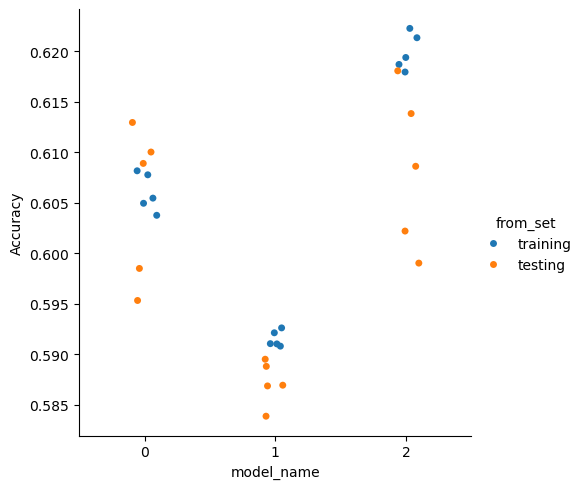

In [41]:
sns.catplot(data = cv_results_my, x='model_name', y='Accuracy', hue='from_set')

plt.show()

In [42]:
# THIS IS IT

C:\Users\HORNYAK2\AppData\Local\Temp\ipykernel_22052\548788328.py:1: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.catplot(data = cv_results_my, x='model_name', y='Accuracy', hue='from_set', kind='point', join=False, errorbar=('ci', 95))
C:\Users\HORNYAK2\AppData\Local\anaconda3\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


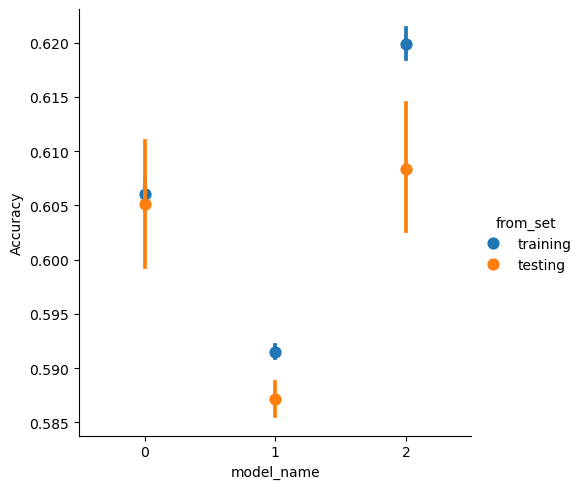

In [43]:
sns.catplot(data = cv_results_my, x='model_name', y='Accuracy', hue='from_set', kind='point', join=False, errorbar=('ci', 95))

plt.show()

C:\Users\HORNYAK2\AppData\Local\Temp\ipykernel_22052\1471780358.py:1: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.catplot(data = cv_results_my, x='model_name', y='Accuracy', hue= 'from_set', kind='point', join=False,
C:\Users\HORNYAK2\AppData\Local\anaconda3\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


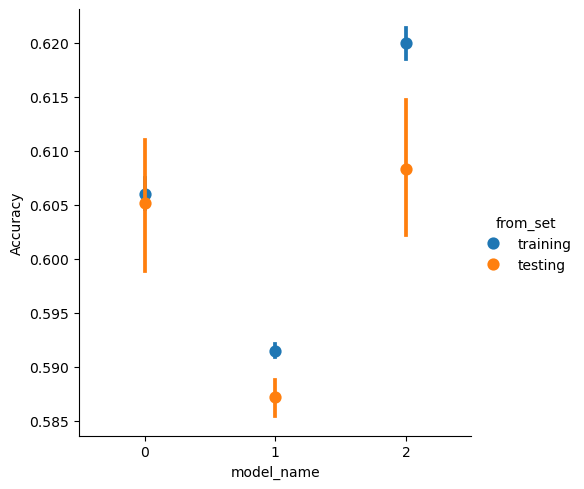

In [44]:
sns.catplot(data = cv_results_my, x='model_name', y='Accuracy', hue= 'from_set', kind='point', join=False,
            errorbar=('ci', 95))

plt.show()

C:\Users\HORNYAK2\AppData\Local\Temp\ipykernel_22052\758286962.py:1: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.catplot(data = cv_results_my.loc[ cv_results_my.from_set == 'testing', :], x='model_name', y='Accuracy', kind='point', join=False,
C:\Users\HORNYAK2\AppData\Local\anaconda3\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


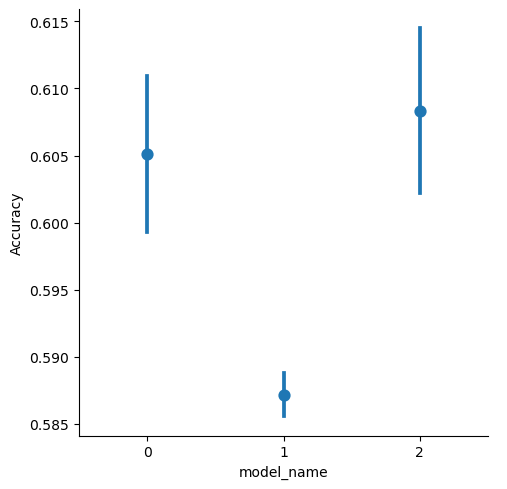

In [45]:
sns.catplot(data = cv_results_my.loc[ cv_results_my.from_set == 'testing', :], x='model_name', y='Accuracy', kind='point', join=False,
            errorbar=('ci', 95))

plt.show()

Model Notes: Model 2 had the best accuracy. Its confidence level and mean fall within the confidence level and mean for Model 0. I am not confident its accuracy is doing better than Model 0. Further, Model 2's testing data performs worse than it does predicting probabilities on training data. So Model 2 is not a good model. 

Model 0 performs the best. Its accuracy on predicting probabilities for the events falls within the confidenc level and mean on the training data. Therefore, Model 0 performs the best.

### Model 1 - No Categorical Encoding 

* Same code as above except letting the categorical encoding happen within the formula when fitted
* Interesting Note - the results were the SAME!
  

In [46]:
def train_and_test_logistic_with_cv(mod_name, a_formula, data_df, x_names, y_name, cv, threshold=0.5):
    # separate the inputs and output
    input_df = data_df.loc[ :, x_names ].copy()
    
    # initialize the performance metric storage lists
    train_res = []
    test_res = []
    
    # SPLIT the data and iterate over the folds
    for train_id, test_id in cv.split( input_df.to_numpy(), data_df[ y_name ].to_numpy() ):
        # subset the training and test splits within each fold
        train_data_temp = data_df.iloc[ train_id, :].copy()
        test_data_temp = data_df.iloc[ test_id, :].copy()

        # create variable to only store continuous inputs for Standardization
        song_features = ['danceability','energy','loudness','speechiness','acousticness','instrumentalness','liveness','valence','tempo','duration_ms']
        song_categories = ['playlist_genre','key','mode']

        # Initialize StandardScaler
        scaler = StandardScaler()

        # Standardize the training data continuous inputs
        song_features_numpy_train = train_data_temp[song_features].copy().to_numpy()
        song_features_standardize_train = scaler.fit_transform(song_features_numpy_train)
        song_features_standardize_df_train = pd.DataFrame(song_features_standardize_train, columns = song_features)

        # Standardize the training data continuous inputs
        song_features_numpy_test = test_data_temp[song_features].copy().to_numpy()
        song_features_standardize_test = scaler.transform(song_features_numpy_test)
        song_features_standardize_df_test = pd.DataFrame(song_features_standardize_test, columns = song_features)

        # Bring standardized inputs back into data frame; replacing existing non-standardized columns
        train_data = train_data_temp.drop(columns = song_features).copy()
        #train_data[song_features] = song_features_standardize_df
        train_data['danceability'] = song_features_standardize_df_train.danceability.values
        train_data['loudness'] = song_features_standardize_df_train.loudness.values
        train_data['energy'] = song_features_standardize_df_train.energy.values
        train_data['speechiness'] = song_features_standardize_df_train.speechiness.values
        train_data['acousticness'] = song_features_standardize_df_train.acousticness.values
        train_data['instrumentalness'] = song_features_standardize_df_train.instrumentalness.values
        train_data['liveness'] = song_features_standardize_df_train.liveness.values
        train_data['valence'] = song_features_standardize_df_train.valence.values
        train_data['tempo'] = song_features_standardize_df_train.tempo.values
        train_data['duration_ms'] = song_features_standardize_df_train.duration_ms.values

        # Bring standardized inputs back into data frame; replacing existing non-standardized columns
        test_data = test_data_temp.drop(columns = song_features).copy()
        #test_data[song_features] = song_features_standardize_df
        test_data['danceability'] = song_features_standardize_df_test.danceability.values
        test_data['loudness'] = song_features_standardize_df_test.loudness.values
        test_data['energy'] = song_features_standardize_df_test.energy.values
        test_data['speechiness'] = song_features_standardize_df_test.speechiness.values
        test_data['acousticness'] = song_features_standardize_df_test.acousticness.values
        test_data['instrumentalness'] = song_features_standardize_df_test.instrumentalness.values
        test_data['liveness'] = song_features_standardize_df_test.liveness.values
        test_data['valence'] = song_features_standardize_df_test.valence.values
        test_data['tempo'] = song_features_standardize_df_test.tempo.values
        test_data['duration_ms'] = song_features_standardize_df_test.duration_ms.values
        
        # FIT the model on the TRAINING data within the current FOLD
        a_mod = smf.logit(formula=a_formula, data=train_data).fit()
        
        # PREDICT the TRAINING within each FOLD
        train_copy = train_data.copy()
        train_copy['pred_probability'] = a_mod.predict( train_data )
        train_copy['pred_class'] = np.where( train_copy.pred_probability > threshold, 1, 0 )
        
        # PREDICT the TESTING within each FOLD
        test_copy = test_data.copy()
        test_copy['pred_probability'] = a_mod.predict( test_data )
        test_copy['pred_class'] = np.where( test_copy.pred_probability > threshold, 1, 0)
        
        # calculate the PERFORMANCE METRIC on the TRAINING SET within the FOLD
        train_res.append( np.mean( train_copy[ y_name ] == train_copy.pred_class ) )
        
        # calculate the PERFORMANCE METRIC on the TESTING SET within the FOLD
        test_res.append( np.mean( test_copy[ y_name ] == test_copy.pred_class ) )
    
    # book keeping to store the results
    train_df = pd.DataFrame({'Accuracy': train_res})
    train_df['from_set'] = 'training'
    train_df['fold_id'] = train_df.index + 1
    
    test_df = pd.DataFrame({'Accuracy': test_res})
    test_df['from_set'] = 'testing'
    test_df['fold_id'] = test_df.index + 1
    
    # combine the splits together
    res_df = pd.concat([train_df, test_df], ignore_index=True)
    
    # add information about the model
    res_df['model_name'] = mod_name
    res_df['model_formula'] = a_formula
    res_df['num_coefs'] = len( a_mod.params )
    res_df['threshold'] = threshold
    
    return res_df

In [47]:
results_list = []

for m in range( len(formula_list) ):
    print( '-- Formula ID %d --' % m )

    try:
        results_list.append( train_and_test_logistic_with_cv(m, formula_list[m], data_df=song_clean_copy_df, x_names=input_names, y_name=output_name, cv=kf) )
    except:
        # what happens if there is an ERROR
        print( ' !!! Formula ID %d could NOT fit !!! ' % m)

-- Formula ID 0 --
Optimization terminated successfully.
         Current function value: 0.657498
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.658162
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.657736
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.656319
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.656153
         Iterations 5
-- Formula ID 1 --
Optimization terminated successfully.
         Current function value: 0.665737
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.665690
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.665803
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.665398
         Iterations 5
Optimization terminated successfully.
      

In [48]:
len( results_list )

3

In [49]:
cv_results = pd.concat( results_list, ignore_index=True )

In [50]:
cv_results

,Accuracy,from_set,fold_id,model_name,model_formula,num_coefs,threshold
0,0.605449,training,1,0,track_pop_median ~ playlist_genre + mode + key...,28,0.5
1,0.603747,training,2,0,track_pop_median ~ playlist_genre + mode + key...,28,0.5
2,0.604937,training,3,0,track_pop_median ~ playlist_genre + mode + key...,28,0.5
3,0.607758,training,4,0,track_pop_median ~ playlist_genre + mode + key...,28,0.5
4,0.608155,training,5,0,track_pop_median ~ playlist_genre + mode + key...,28,0.5
5,0.610014,testing,1,0,track_pop_median ~ playlist_genre + mode + key...,28,0.5
6,0.612943,testing,2,0,track_pop_median ~ playlist_genre + mode + key...,28,0.5
7,0.608887,testing,3,0,track_pop_median ~ playlist_genre + mode + key...,28,0.5
8,0.595309,testing,4,0,track_pop_median ~ playlist_genre + mode + key...,28,0.5
9,0.598484,testing,5,0,track_pop_median ~ playlist_genre + mode + key...,28,0.5


C:\Users\HORNYAK2\AppData\Local\anaconda3\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


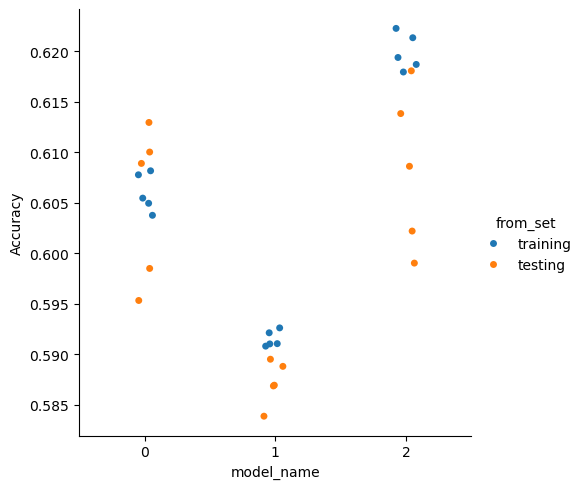

In [51]:
sns.catplot(data = cv_results, x='model_name', y='Accuracy', hue='from_set')

plt.show()

C:\Users\HORNYAK2\AppData\Local\Temp\ipykernel_22052\3618870967.py:7: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(data = cv_results, x='model_name', y='Accuracy', hue='from_set', join=False, ax=ax)


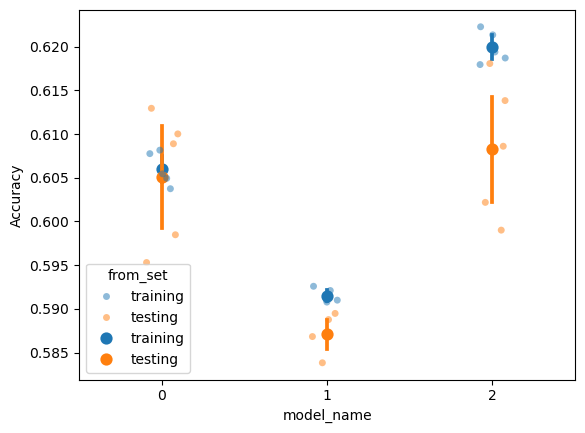

In [52]:
# this stripplot gives more context

fig, ax = plt.subplots()

sns.stripplot(data = cv_results, x='model_name', y='Accuracy', hue='from_set', alpha=0.5, ax=ax)

sns.pointplot(data = cv_results, x='model_name', y='Accuracy', hue='from_set', join=False, ax=ax)

plt.show()

C:\Users\HORNYAK2\AppData\Local\Temp\ipykernel_22052\3807446522.py:1: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.catplot(data = cv_results, x='model_name', y='Accuracy', hue='from_set', kind='point', join=False, errorbar=('ci', 95))
C:\Users\HORNYAK2\AppData\Local\anaconda3\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


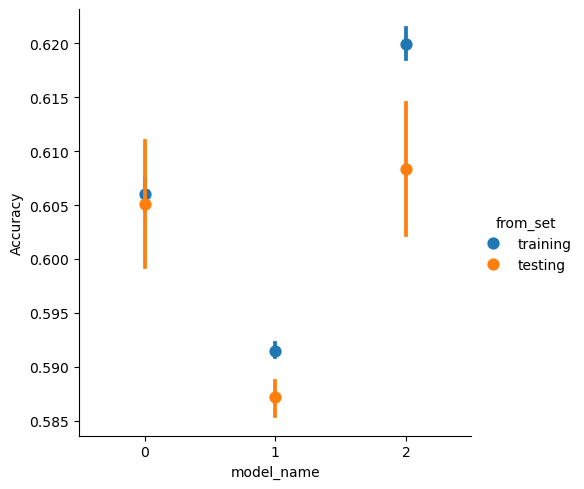

In [53]:
sns.catplot(data = cv_results, x='model_name', y='Accuracy', hue='from_set', kind='point', join=False, errorbar=('ci', 95))

plt.show()

C:\Users\HORNYAK2\AppData\Local\Temp\ipykernel_22052\3978875661.py:1: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.catplot(data = cv_results.loc[ cv_results.from_set == 'testing', :],
C:\Users\HORNYAK2\AppData\Local\anaconda3\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


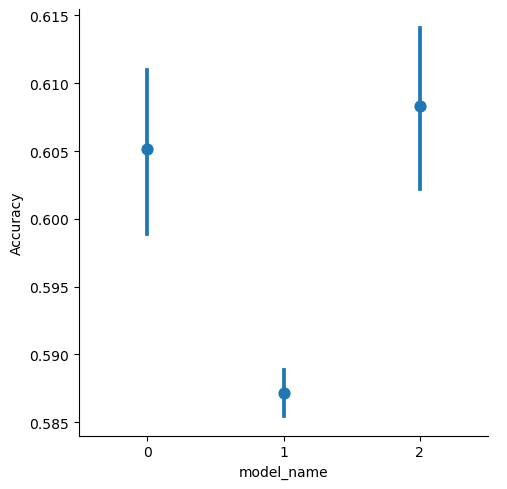

In [54]:
sns.catplot(data = cv_results.loc[ cv_results.from_set == 'testing', :],
            x='model_name', y='Accuracy', kind='point', join=False,
            errorbar=('ci', 95))

plt.show()

### Model 2 - Cross Validation Score with Pipeline

* Categorical Encoding occurs when variable `X` is created...making all variables numeric
* I believe that standarization occurs within the fold, although in this model i believe it is also standardizing the encoded categorical variables
* This was a first pass at using pipelines. I explore further below

In [55]:
def logistic_cross_val_score(mod_name, a_formula, init_mod, data_df, cv):
    # create the feature and output arrays using the formula
    y, X = dmatrices( a_formula, data=data_df )

    #Build the pipeline: scaling happens inside each CV fold
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', init_mod)
    ])
    
    # train and test within each fold - return the test set scores
    test_res = cross_val_score(pipe, X, y.ravel(), cv=cv)
    
    # book keeping
    res_df = pd.DataFrame({'Accuracy': test_res})
    res_df['fold_id'] = res_df.index + 1
    res_df['model_name'] = mod_name
    res_df['model_formula'] = a_formula
    res_df['num_coefs'] = X.shape[1]
    # he number of columns of the feature array equals the number of coefficients. We can get the number of coefficients by just accessing the number of columns of that project. Then we return the result.
    
    return res_df

Initialize the SKLEARN Logistic Regression model to be CONSISTENT with statsmodels.

In [56]:
sk_min_loss = LogisticRegression(penalty=None, solver='lbfgs', fit_intercept=False, max_iter=25001)

In [57]:
cv_score_list = []

for m in range(len(formula_list)):
    print('-- Formula ID %d --' % m)

    try:
        cv_score_list.append( logistic_cross_val_score(m, formula_list[m], init_mod=sk_min_loss, data_df=song_clean_copy_df, cv=kf) )

    except:
        # what happens if there is an ERROR
        print( ' !!! Formula ID %d could NOT fit !!! ' % m)

-- Formula ID 0 --
-- Formula ID 1 --
-- Formula ID 2 --


In [58]:
cv_score_df = pd.concat( cv_score_list, ignore_index=True )

In [59]:
cv_score_df

,Accuracy,fold_id,model_name,model_formula,num_coefs
0,0.607370,1,0,track_pop_median ~ playlist_genre + mode + key...,28
1,0.613296,2,0,track_pop_median ~ playlist_genre + mode + key...,28
2,0.608887,3,0,track_pop_median ~ playlist_genre + mode + key...,28
3,0.596896,4,0,track_pop_median ~ playlist_genre + mode + key...,28
4,0.597778,5,0,track_pop_median ~ playlist_genre + mode + key...,28
5,0.587094,1,1,track_pop_median ~ (danceability + energy + lo...,56
6,0.588256,2,1,track_pop_median ~ (danceability + energy + lo...,56
7,0.589843,3,1,track_pop_median ~ (danceability + energy + lo...,56
8,0.584729,4,1,track_pop_median ~ (danceability + energy + lo...,56
9,0.583848,5,1,track_pop_median ~ (danceability + energy + lo...,56


C:\Users\HORNYAK2\AppData\Local\Temp\ipykernel_22052\1225143275.py:1: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.catplot(data = cv_score_df, x='model_name', y='Accuracy', kind='point', join=False,
C:\Users\HORNYAK2\AppData\Local\anaconda3\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


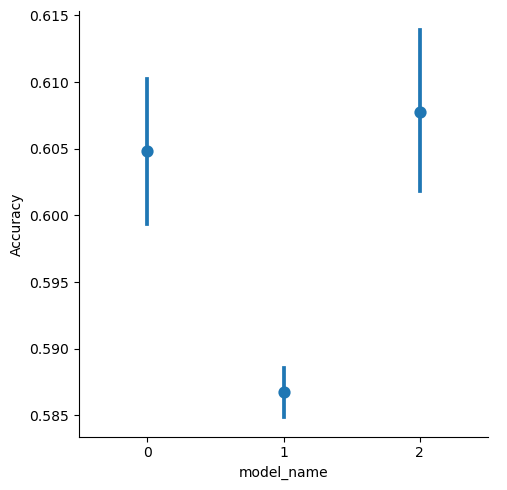

In [60]:
sns.catplot(data = cv_score_df, x='model_name', y='Accuracy', kind='point', join=False,
            errorbar=('ci', 95))

plt.show()

### Model 3 - Cross Validation Score with Pipeline - Pass Through Categorical Variables

* Categorical Variables are created in variable `X` from dmatrices() which stores all columns as numeric.
* Passing through the Encoded Categoricals within the Pipeline/Fold
* StandardScaler lives inside the Pipeline, which is inside Cross_Val_Score
* created variable to store the encoded categories from `X`, to ensure I do not standardized them with continuous columns in StandardScaler
* Cross_Val_Score performs the train/test split inside the cross-validation loop, which the preprocessing steps are wrapped in the PipeLine
* For each fold, the training set is passed into the pipeline
* StandardScaler().fit() is called only on the training portion of that fold
* The fitted scalar transforms both the training and test fold
* Intercept is set to `False` in the `init_mod` variable which stores the LogisticRegression
* However, i set the code to account for an Intercept if one should exist

In [61]:
def logistic_cross_val_scores(mod_name, a_formula, init_mod, data_df, cv):

    # Create y and X using patsy's formula
    y, X = dmatrices(a_formula, data=data_df, return_type='dataframe')

    # Get patsy-generated column names
    col_names = X.columns

    # Identify dummy columns (patsy names them like variable[level])
    dummy_cols = [c for c in col_names if "[" in c and "]" in c]

    # Identify real numeric columns (exclude dummy columns and intercept)
    intercept_col = [c for c in X.columns if c.lower() == "intercept"]
    num_cols = [
        c for c in col_names
        if c not in dummy_cols and c.lower() != 'intercept'
    ]

    # Build preprocessing: scale numeric, passthrough categorical dummies
    preprocessor = ColumnTransformer(
        transformers=[
            ("scale_numeric", StandardScaler(), num_cols),
            ("keep_dummies", "passthrough", dummy_cols + intercept_col)
        ]
    )

    # Build pipeline
    pipe = Pipeline([
        ('preprocess', preprocessor),
        ('model', init_mod)
    ])

    # Cross-validation accuracy
    test_res = cross_val_score(pipe, X, y.values.ravel(), cv=cv)

    # Bookkeeping
    res_df = pd.DataFrame({'Accuracy': test_res})
    res_df['fold_id'] = res_df.index + 1
    res_df['model_name'] = mod_name
    res_df['model_formula'] = a_formula
    res_df['num_coefs'] = X.shape[1]

    return res_df

In [62]:
sk_min_loss = LogisticRegression(penalty=None, solver='lbfgs', fit_intercept=False, max_iter=25001)

In [63]:
cv_score_list_andrew = []

for m in range(len(formula_list_trim)):
    print('-- Formula ID %d --' % m)

    try:
        cv_score_list_andrew.append( logistic_cross_val_scores(m,formula_list_trim[m], init_mod=sk_min_loss, data_df=song_clean_copy_df, cv=kf) )

    except:
        # what happens if there is an ERROR
        print( ' !!! Formula ID %d could NOT fit !!! ' % m)

-- Formula ID 0 --
-- Formula ID 1 --
-- Formula ID 2 --


In [64]:
cv_score_andrew_df = pd.concat( cv_score_list_andrew, ignore_index=True )


C:\Users\HORNYAK2\AppData\Local\Temp\ipykernel_22052\1025595306.py:1: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.catplot(data = cv_score_andrew_df, x='model_name', y='Accuracy', kind='point', join=False,
C:\Users\HORNYAK2\AppData\Local\anaconda3\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


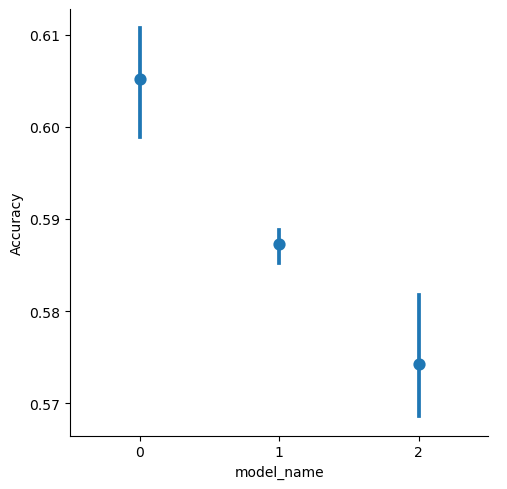

In [65]:
sns.catplot(data = cv_score_andrew_df, x='model_name', y='Accuracy', kind='point', join=False,
            errorbar=('ci', 95))

plt.show()

In [66]:
#####################################################################################

### Model 4 - Cross Validation Score with Pipeline - Pass Through Categorical Variables - Store Train and Test Scores

* Same code as in function for Model 3, except the book keeping stores Train and Test results separately
* I do not feel confident in being to explain the Train and Test scores for `Model 2` are different compared to the first model which is why I did not use it. Although using Cross_Val_score I feel confident in being able to use.

In [67]:
def logistic_cross_val_scores_with_train(
    mod_name, a_formula, init_mod, data_df, cv
):

    # ---- Patsy Design Matrices ----
    y, X = dmatrices(a_formula, data=data_df, return_type='dataframe')

    # Identify dummy columns created by patsy
    dummy_cols = [c for c in X.columns if "[" in c and "]" in c]

    # Identify intercept (sometimes present)
    intercept_col = [c for c in X.columns if c.lower() == "intercept"]

    # Continuous numeric columns = all non-dummies and non-intercept
    num_cols = [
        c for c in X.columns
        if c not in dummy_cols and c not in intercept_col
    ]

    # ---- Preprocessing Pipeline ----
    preprocessor = ColumnTransformer(
        transformers=[
            ("scale_numeric", StandardScaler(), num_cols),
            ("keep_dummies", "passthrough", dummy_cols + intercept_col)
        ]
    )

    pipe = Pipeline([
        ('preprocess', preprocessor),
        ('model', init_mod)
    ])

    # ---- Manual cross-validation loop ----
    train_scores = []
    test_scores = []
    fold_id = 1

    for train_idx, test_idx in cv.split(X, y.values.ravel()):

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # fit model on training fold
        pipe.fit(X_train, y_train.values.ravel())

        # predictions
        y_pred_train = pipe.predict(X_train)
        y_pred_test  = pipe.predict(X_test)

        # compute accuracy (or any metric you prefer)
        train_acc = np.mean(y_pred_train == y_train.values.ravel())
        test_acc  = np.mean(y_pred_test == y_test.values.ravel())

        train_scores.append(train_acc)
        test_scores.append(test_acc)

        fold_id += 1

    # ---- Return both train & test results ----
    res_df = pd.DataFrame({
        "fold": np.arange(1, len(test_scores)+1),
        "train_accuracy": train_scores,
        "test_accuracy": test_scores,
        "model_name": mod_name,
        "model_formula": a_formula,
        "num_coefs": X.shape[1]
    })

    return res_df

In [68]:
cv_score_list_aph= []

for m in range(len(formula_list_trim)):
    print('-- Formula ID %d --' % m)

    try:
        cv_score_list_aph.append( logistic_cross_val_scores_with_train(m,formula_list_trim[m], init_mod=sk_min_loss, data_df=song_clean_copy_df, cv=kf) )

    except:
        # what happens if there is an ERROR
        print( ' !!! Formula ID %d could NOT fit !!! ' % m)

-- Formula ID 0 --
-- Formula ID 1 --
-- Formula ID 2 --


In [69]:
cv_score_list_aph

[   fold  train_accuracy  test_accuracy  model_name  \
 0     1        0.605449       0.610014           0   
 1     2        0.603791       0.612767           0   
 2     3        0.604937       0.608887           0   
 3     4        0.607847       0.595309           0   
 4     5        0.608111       0.598660           0   
 
                                        model_formula  num_coefs  
 0  track_pop_median ~ playlist_genre + mode + key...         28  
 1  track_pop_median ~ playlist_genre + mode + key...         28  
 2  track_pop_median ~ playlist_genre + mode + key...         28  
 3  track_pop_median ~ playlist_genre + mode + key...         28  
 4  track_pop_median ~ playlist_genre + mode + key...         28  ,
    fold  train_accuracy  test_accuracy  model_name  \
 0     1        0.590857       0.587094           1   
 1     2        0.591007       0.589667           1   
 2     3        0.590787       0.588785           1   
 3     4        0.592065       0.584024      

In [70]:
cv_score_aph_df = pd.concat( cv_score_list_aph, ignore_index=True )

In [71]:
cv_score_aph_df

,fold,train_accuracy,test_accuracy,model_name,model_formula,num_coefs
0,1,0.605449,0.610014,0,track_pop_median ~ playlist_genre + mode + key...,28
1,2,0.603791,0.612767,0,track_pop_median ~ playlist_genre + mode + key...,28
2,3,0.604937,0.608887,0,track_pop_median ~ playlist_genre + mode + key...,28
3,4,0.607847,0.595309,0,track_pop_median ~ playlist_genre + mode + key...,28
4,5,0.608111,0.598660,0,track_pop_median ~ playlist_genre + mode + key...,28
5,1,0.590857,0.587094,1,track_pop_median ~ (danceability + energy + lo...,56
6,2,0.591007,0.589667,1,track_pop_median ~ (danceability + energy + lo...,56
7,3,0.590787,0.588785,1,track_pop_median ~ (danceability + energy + lo...,56
8,4,0.592065,0.584024,1,track_pop_median ~ (danceability + energy + lo...,56
9,5,0.592682,0.587022,1,track_pop_median ~ (danceability + energy + lo...,56


### Model 5 - Cross Validation Score with Pipeline - Pass Through Categorical Variables - Store Train and Test Scores in same column

* Same code as in function for Model 4, except the book keeping stores Train and Test results in the ame column
* I do not feel confident in being to explain the Train and Test scores for `Model 2` are different compared to the first model which is why I did not use it. Although using Cross_Val_score I feel confident in being able to use.

In [72]:
def logistic_cross_val_scores_long(
    mod_name, a_formula, init_mod, data_df, cv
):
    # ---- Patsy Design Matrices ----
    y, X = dmatrices(a_formula, data=data_df, return_type='dataframe')

    dummy_cols = [c for c in X.columns if "[" in c and "]" in c]
    intercept_col = [c for c in X.columns if c.lower() == "intercept"]
    num_cols = [c for c in X.columns if c not in dummy_cols and c not in intercept_col]

    # ---- Preprocessing Pipeline ----
    preprocessor = ColumnTransformer(
        transformers=[
            ("scale_numeric", StandardScaler(), num_cols),
            ("keep_dummies", "passthrough", dummy_cols + intercept_col)
        ]
    )

    pipe = Pipeline([
        ('preprocess', preprocessor),
        ('model', init_mod)
    ])

    # ---- Collect results in long format ----
    records = []
    fold_num = 1

    for train_idx, test_idx in cv.split(X, y.values.ravel()):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        pipe.fit(X_train, y_train.values.ravel())

        # Compute train and test accuracy
        train_acc = np.mean(pipe.predict(X_train) == y_train.values.ravel())
        test_acc  = np.mean(pipe.predict(X_test)  == y_test.values.ravel())

        # Append train accuracy row
        records.append({
            "fold": fold_num,
            "data_split": "train",
            "accuracy": train_acc,
            "model_name": mod_name,
            "model_formula": a_formula,
            "num_coefs": X.shape[1]
        })

        # Append test accuracy row
        records.append({
            "fold": fold_num,
            "data_split": "test",
            "accuracy": test_acc,
            "model_name": mod_name,
            "model_formula": a_formula,
            "num_coefs": X.shape[1]
        })

        fold_num += 1

    return pd.DataFrame(records)

In [73]:
cv_score_list_aph2= []

for m in range(len(formula_list_trim)):
    print('-- Formula ID %d --' % m)

    try:
        cv_score_list_aph2.append( logistic_cross_val_scores_long(m,formula_list_trim[m], init_mod=sk_min_loss, data_df=song_clean_copy_df, cv=kf) )

    except:
        # what happens if there is an ERROR
        print( ' !!! Formula ID %d could NOT fit !!! ' % m)

-- Formula ID 0 --
-- Formula ID 1 --
-- Formula ID 2 --


In [74]:
cv_score_aph_df2 = pd.concat( cv_score_list_aph2, ignore_index=True )

In [75]:
cv_score_aph_df2

,fold,data_split,accuracy,model_name,model_formula,num_coefs
0,1,train,0.605449,0,track_pop_median ~ playlist_genre + mode + key...,28
1,1,test,0.610014,0,track_pop_median ~ playlist_genre + mode + key...,28
2,2,train,0.603791,0,track_pop_median ~ playlist_genre + mode + key...,28
3,2,test,0.612767,0,track_pop_median ~ playlist_genre + mode + key...,28
4,3,train,0.604937,0,track_pop_median ~ playlist_genre + mode + key...,28
5,3,test,0.608887,0,track_pop_median ~ playlist_genre + mode + key...,28
6,4,train,0.607847,0,track_pop_median ~ playlist_genre + mode + key...,28
7,4,test,0.595309,0,track_pop_median ~ playlist_genre + mode + key...,28
8,5,train,0.608111,0,track_pop_median ~ playlist_genre + mode + key...,28
9,5,test,0.598660,0,track_pop_median ~ playlist_genre + mode + key...,28


C:\Users\HORNYAK2\AppData\Local\anaconda3\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


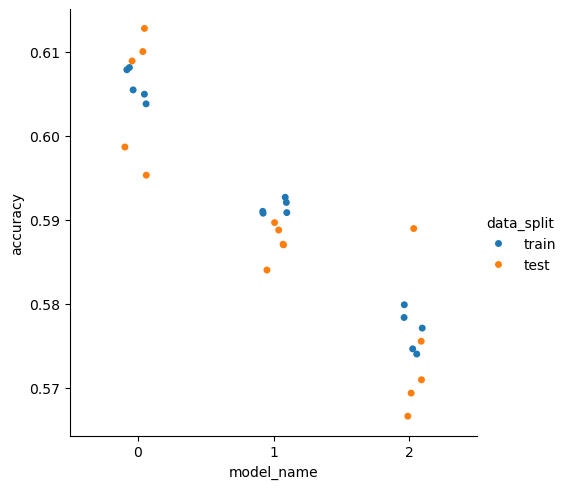

In [76]:
sns.catplot(data = cv_score_aph_df2, x='model_name', y='accuracy', hue='data_split')

plt.show()

C:\Users\HORNYAK2\AppData\Local\Temp\ipykernel_22052\3713865044.py:1: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.catplot(data = cv_score_aph_df2, x='model_name', y='accuracy', kind='point', join=False, errorbar=('ci', 95))
C:\Users\HORNYAK2\AppData\Local\anaconda3\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


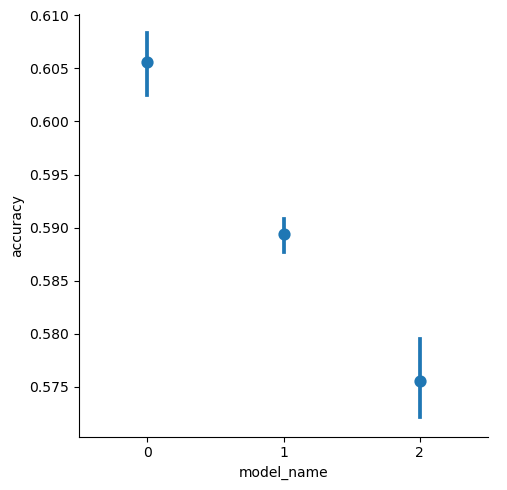

In [77]:
sns.catplot(data = cv_score_aph_df2, x='model_name', y='accuracy', kind='point', join=False, errorbar=('ci', 95))

plt.show()

C:\Users\HORNYAK2\AppData\Local\Temp\ipykernel_22052\1206563379.py:1: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.catplot(data = cv_score_aph_df2, x='model_name', y='accuracy', hue='data_split', kind='point', join=False, errorbar=('ci', 95))
C:\Users\HORNYAK2\AppData\Local\anaconda3\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


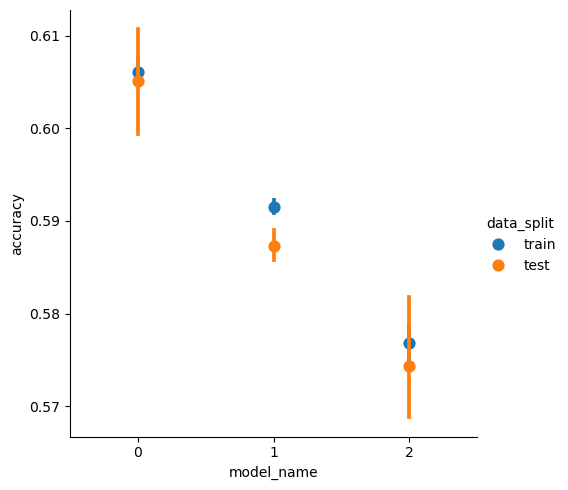

In [78]:
sns.catplot(data = cv_score_aph_df2, x='model_name', y='accuracy', hue='data_split', kind='point', join=False, errorbar=('ci', 95))

plt.show()

C:\Users\HORNYAK2\AppData\Local\Temp\ipykernel_22052\3231133838.py:1: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.catplot(data = cv_score_aph_df2.loc[ cv_score_aph_df2.data_split == 'test', :], x='model_name', y='accuracy', hue='data_split', kind='point', join=False, errorbar=('ci', 95))
C:\Users\HORNYAK2\AppData\Local\anaconda3\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


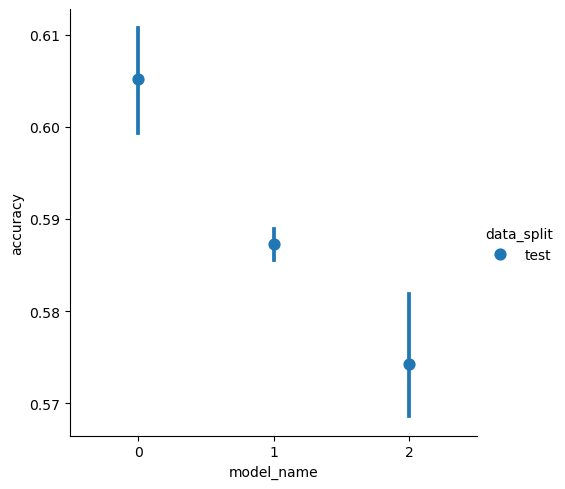

In [79]:
sns.catplot(data = cv_score_aph_df2.loc[ cv_score_aph_df2.data_split == 'test', :], x='model_name', y='accuracy', hue='data_split', kind='point', join=False, errorbar=('ci', 95))

plt.show()

Final Notes:

Model_name 0 performs the best which is the Simplest model with only 28 coefficients. 

Model_name 0 and 1 show about the same performance compared to Statsmodel above. 

Model_name 2 has worse accuracy on train and test data. In this model, the test data performs well against the train data and there is no overfitting